In [1]:
pip install pandas numpy matplotlib seaborn jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("sales_data.csv")
df.head()

,OrderID,Date,Region,Product,Category,Quantity,Price,Customer
0,1001,2023-01-05,North,Laptop,Electronics,2,50000,Amit
1,1002,2023-01-10,South,Mobile,Electronics,3,20000,Ravi
2,1003,2023-01-15,East,Tablet,Electronics,1,30000,Neha
3,1004,2023-02-01,West,Headphones,Accessories,5,2000,Priya
4,1005,2023-02-10,North,Mouse,Accessories,10,500,Anil


In [5]:
df.shape

(10, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   OrderID   10 non-null     int64 
 1   Date      10 non-null     object
 2   Region    10 non-null     object
 3   Product   10 non-null     object
 4   Category  10 non-null     object
 5   Quantity  10 non-null     int64 
 6   Price     10 non-null     int64 
 7   Customer  10 non-null     object
dtypes: int64(3), object(5)
memory usage: 772.0+ bytes


In [7]:
df.describe()

,OrderID,Quantity,Price
count,10.00000,10.000000,10.000000
mean,1005.50000,3.300000,21900.000000
std,3.02765,2.668749,18364.821444
min,1001.00000,1.000000,500.000000
25%,1003.25000,2.000000,5250.000000
50%,1005.50000,2.500000,20000.000000
75%,1007.75000,3.750000,30000.000000
max,1010.00000,10.000000,50000.000000


In [8]:
df.isnull().sum()

,0
OrderID,0
Date,0
Region,0
Product,0
Category,0
Quantity,0
Price,0
Customer,0


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df['Sales'] = df['Quantity'] * df['Price']
df.head()

,OrderID,Date,Region,Product,Category,Quantity,Price,Customer,Sales
0,1001,2023-01-05,North,Laptop,Electronics,2,50000,Amit,100000
1,1002,2023-01-10,South,Mobile,Electronics,3,20000,Ravi,60000
2,1003,2023-01-15,East,Tablet,Electronics,1,30000,Neha,30000
3,1004,2023-02-01,West,Headphones,Accessories,5,2000,Priya,10000
4,1005,2023-02-10,North,Mouse,Accessories,10,500,Anil,5000


In [12]:
total_sales = df['Sales'].sum()
print("Total Revenue:", total_sales)

Total Revenue: 421000


In [13]:
product_sales = df.groupby('Product')['Sales'].sum()
print(product_sales)

Product
Headphones     10000
Keyboard        6000
Laptop        150000
Mobile        100000
Monitor        30000
Mouse           5000
Tablet        120000
Name: Sales, dtype: int64


In [14]:
df['Month'] = df['Date'].dt.month

In [15]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
1    190000
2     15000
3     90000
4     36000
5     90000
Name: Sales, dtype: int64


In [16]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
East      70000
North    135000
South    200000
West      16000
Name: Sales, dtype: int64


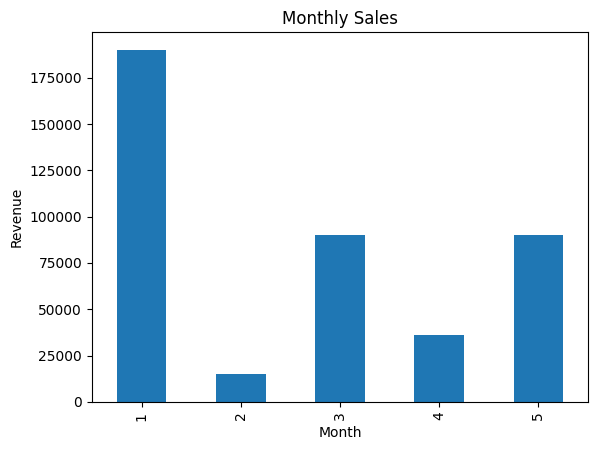

In [17]:
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

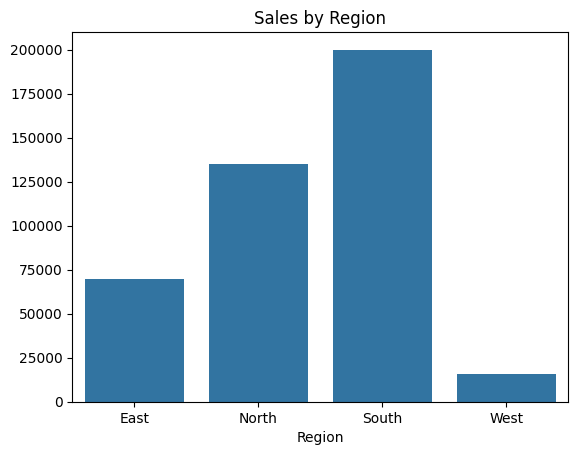

In [18]:
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.show()

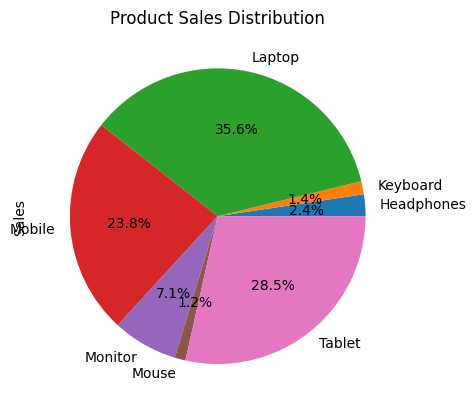

In [19]:
product_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Product Sales Distribution")
plt.show()

In [20]:
plt.savefig("monthly_sales.png")

<Figure size 640x480 with 0 Axes>